# 🚕 Q-Learning en Taxi-v4 — Trabajo en casa

En este ejercicio aplicará Q-Learning al ambiente **Taxi-v4** de Gymnasium.

La lógica es la misma trabajada en FrozenLake:

$$
(s_t,a_t) \rightarrow (r_{t+1},s_{t+1})
$$

y la actualización:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+
\alpha
\left[
r_{t+1}
+
\gamma \max_a Q(s_{t+1},a)
-
Q(s_t,a_t)
\right]
$$

## Objetivo

Implementar y analizar un agente Q-Learning capaz de aprender a recoger un pasajero y llevarlo a su destino.


## 1. Preparación

Instale Gymnasium si es necesario:

```bash
pip install gymnasium[toy-text]
```


In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

from IPython.display import HTML
from matplotlib import animation


**Semilla** (añadida para que los resultados del notebook sean reproducibles).

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Las animaciones se guardan con frames JPEG para que el notebook no pese decenas de MB.
plt.rcParams["animation.frame_format"] = "jpeg"

## 2. Crear el ambiente

Taxi tiene un número de estados mucho mayor que FrozenLake.

Cada estado codifica:

- posición del taxi,
- ubicación del pasajero,
- destino del pasajero.

Las acciones posibles son:

| Acción | Significado |
|---|---|
| 0 | South |
| 1 | North |
| 2 | East |
| 3 | West |
| 4 | Pickup |
| 5 | Dropoff |


In [3]:
env = gym.make("Taxi-v4", render_mode="rgb_array")

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)


Número de estados: 500
Número de acciones: 6


### Pregunta 1

¿Cuántos estados y cuántas acciones tiene Taxi-v4?

Explique brevemente por qué Taxi tiene muchos más estados que FrozenLake.


**Respuesta:**

Taxi-v4 tiene **500 estados** y **6 acciones** (salida de la celda anterior).

El estado combina tres variables independientes: posición del taxi (5×5 = 25 celdas), ubicación del pasajero (4 paradas R, G, Y, B o dentro del taxi = 5) y destino (4 paradas): $25\times5\times4=500$. FrozenLake 4×4 solo codifica la posición del agente (16 estados), por eso Taxi es mucho más grande.

## 3. Observar una interacción

Ejecute una acción aleatoria y observe qué devuelve el ambiente.


In [4]:
state, info = env.reset(seed=42)

action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

print("Estado:", state)
print("Acción:", action)
print("Nuevo estado:", next_state)
print("Recompensa:", reward)
print("Terminated:", terminated)


Estado: 386
Acción: 5
Nuevo estado: 386
Recompensa: -10
Terminated: False


### Pregunta 2

En la interacción anterior identifique:

$$
s_t,\quad a_t,\quad r_{t+1},\quad s_{t+1}
$$

¿Qué representa cada elemento?


**Respuesta:**

En la ejecución con `seed=42`:

- $s_t = 386$: estado codificado (posición del taxi, pasajero y destino) antes de actuar.
- $a_t = 5$ (**Dropoff**): acción aleatoria tomada por el agente.
- $r_{t+1} = -10$: castigo por intentar dejar al pasajero donde no corresponde (dropoff ilegal).
- $s_{t+1} = 386$: el estado no cambia, porque un dropoff ilegal no mueve al taxi ni al pasajero.
- `terminated=False`: el episodio sigue.

## 4. Inicializar la Q-table

Cada fila corresponde a un estado y cada columna a una acción.

Inicialmente:

$$
Q(s,a)=0
$$


In [5]:
n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

print("Shape de Q:", Q.shape)
Q[:5]


Shape de Q: (500, 6)


array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

### Pregunta 3

¿Cuántos valores debe aprender el agente en total?

Calcule:

$$
|\mathcal{S}| \times |\mathcal{A}|
$$


**Respuesta:**

$|\mathcal{S}|\times|\mathcal{A}| = 500 \times 6 = 3000$ valores $Q(s,a)$, que coincide con `Q.shape = (500, 6)`.

## 5. Política $\epsilon$-greedy

Implemente una función que:

- con probabilidad $\epsilon$ seleccione una acción aleatoria;
- en otro caso seleccione:

$$
\arg\max_a Q(s,a)
$$

### Actividad 1
Complete la función.


In [6]:
def choose_action(Q, state, epsilon, env):
    # 1. decidir si explorar o explotar
    if random.random() < epsilon:
        # Explorar: acción aleatoria del espacio de acciones
        return env.action_space.sample()

    # 2. Explotar: argmax_a Q(s,a); si hay empate, se elige al azar entre las mejores
    q_values = Q[state]
    best_actions = np.flatnonzero(q_values == np.max(q_values))
    return int(np.random.choice(best_actions))

## 6. Actualización de Q

La regla de actualización es:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r+
\gamma\max_{a'}Q(s',a')
-
Q(s,a)
\right]
$$

### Actividad 2
Complete la función.


In [7]:
def update_q(Q, state, action, reward, next_state, alpha, gamma):
    # Calcular el target: r + gamma * max_a' Q(s',a')
    # (Si s' es terminal, su fila de Q nunca se actualiza porque el episodio termina
    #  al llegar allí; permanece en 0 y el target se reduce a r.)
    td_target = reward + gamma * np.max(Q[next_state])

    # Calcular el error TD
    td_error = td_target - Q[state, action]

    # Actualizar Q[state, action]
    Q[state, action] = Q[state, action] + alpha * td_error
    return td_error

## 7. Entrenamiento

Ahora implemente el ciclo completo de Q-Learning.

En cada episodio:

1. reiniciar el ambiente;
2. escoger una acción;
3. ejecutar `env.step(action)`;
4. actualizar $Q(s,a)$;
5. mover el agente a `next_state`;
6. terminar cuando el episodio finalice.

Use inicialmente:

```python
alpha = 0.1
gamma = 0.95
epsilon = 0.1
episodes = 5000
```

### Actividad 3
Complete la función.


In [8]:
def train_q_learning(
    env,
    Q,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    max_steps=200
):
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(max_steps):

            # TODO 1: escoger acción
            action = choose_action(Q, state, epsilon, env)

            # TODO 2: ejecutar acción en el ambiente
            next_state, reward, terminated, truncated, _ = env.step(action)

            # TODO 3: actualizar Q
            update_q(Q, state, action, reward, next_state, alpha, gamma)

            # TODO 4: actualizar estado y recompensa acumulada
            state = next_state
            total_reward += reward

            # TODO 5: terminar si corresponde
            if terminated or truncated:
                break

        rewards.append(total_reward)

    return Q, rewards

## 8. Entrenar el agente

Ejecute el entrenamiento una vez haya completado las funciones anteriores.


In [9]:
env.reset(seed=SEED)        # fija el generador interno del ambiente
env.action_space.seed(SEED)  # fija el muestreo de acciones aleatorias (exploración)

Q_initial = np.zeros((n_states, n_actions))

Q_trained, rewards = train_q_learning(
    env,
    Q_initial.copy(),
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1
)


## 9. Curva de aprendizaje

Observe cómo cambia la recompensa durante el entrenamiento.


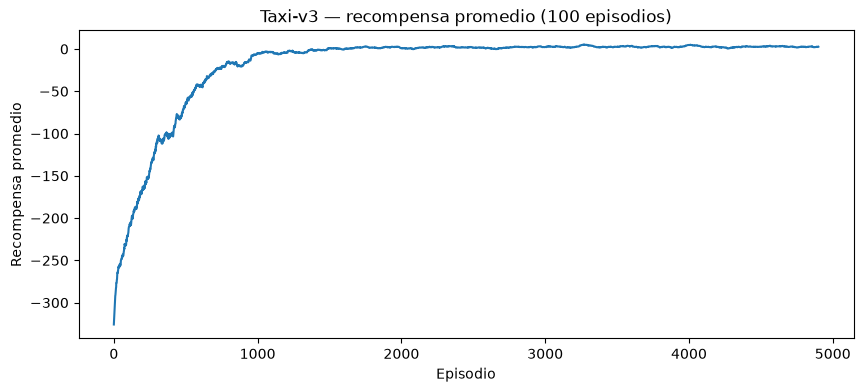

In [10]:
window = 100

moving_average = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))
plt.plot(moving_average)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Taxi-v3 — recompensa promedio ({window} episodios)")
plt.show()


### Pregunta 4

Describa la curva de aprendizaje.

- ¿La recompensa promedio mejora?
- ¿Después de aproximadamente cuántos episodios comienza a estabilizarse?
- ¿El comportamiento observado indica convergencia perfecta o solamente una política razonablemente buena?


In [11]:
# Evidencia para la Pregunta 4: promedio móvil en distintos momentos del entrenamiento
for ep in [100, 250, 500, 1000, 1500, 2000, 3000, 4000, 5000]:
    print(f"episodio {ep:>4}: recompensa promedio de los {window} episodios previos = {np.mean(rewards[ep-window:ep]):7.2f}")

episodio  100: recompensa promedio de los 100 episodios previos = -325.84
episodio  250: recompensa promedio de los 100 episodios previos = -186.73
episodio  500: recompensa promedio de los 100 episodios previos = -101.00
episodio 1000: recompensa promedio de los 100 episodios previos =  -18.96
episodio 1500: recompensa promedio de los 100 episodios previos =   -1.71
episodio 2000: recompensa promedio de los 100 episodios previos =    2.43
episodio 3000: recompensa promedio de los 100 episodios previos =    2.48
episodio 4000: recompensa promedio de los 100 episodios previos =    2.68
episodio 5000: recompensa promedio de los 100 episodios previos =    2.65


**Respuesta:**

- **Sí mejora.** El promedio móvil pasa de unos $-326$ (episodio 100) a $-101$ (episodio 500), $-19$ (episodio 1000) y se vuelve positivo hacia el episodio ~1600.
- **Se estabiliza** a partir de ~2000 episodios, alrededor de $+2.4$ a $+2.7$ (episodios 2000–5000).
- **No es convergencia perfecta:** la curva se mide con $\epsilon=0.1$, así que el 10 % de las acciones siguen siendo aleatorias y bajan la recompensa. Además oscila (desviación ≈ 7.8 en los últimos 500 episodios). La política greedy obtiene en promedio $+7.63$ y 100 % de éxito en 100 episodios de prueba (celda del experimento), es decir, una **política buena**, aunque la curva no demuestra que sea exactamente la óptima.

## 10. Reproducir un episodio

La siguiente función ejecuta una política greedy usando la Q-table aprendida y guarda los frames del episodio.


In [12]:
def play_episode(env, Q, max_steps=200, seed=None):
    state, _ = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for _ in range(max_steps):

        q_values = Q[state]
        max_q = np.max(q_values)

        best_actions = np.flatnonzero(q_values == max_q)
        action = int(np.random.choice(best_actions))

        next_state, reward, terminated, truncated, _ = env.step(action)

        frames.append(env.render())

        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    return frames, total_reward


def frames_to_video(frames, interval=500):
    fig = plt.figure(figsize=(6, 4))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


## 11. Comparar antes y después

Primero observe un Taxi sin entrenamiento usando una Q-table en cero.


In [13]:
frames_initial, reward_initial = play_episode(
    env,
    Q_initial,
    max_steps=50,
    seed=7
)

print("Recompensa total sin entrenamiento:", reward_initial)
frames_to_video(frames_initial, interval=500)


Recompensa total sin entrenamiento: -203


Ahora observe el agente entrenado.


In [14]:
frames_trained, reward_trained = play_episode(
    env,
    Q_trained,
    max_steps=200,
    seed=7
)

print("Recompensa total después del entrenamiento:", reward_trained)
frames_to_video(frames_trained, interval=500)


Recompensa total después del entrenamiento: 10


### Pregunta 5

Compare los dos episodios.

- ¿Qué diferencias observa en el comportamiento del taxi?
- ¿El taxi sin entrenamiento logra completar la tarea?
- ¿El agente entrenado evita acciones innecesarias?
- ¿Qué evidencia visual le permite afirmar que el agente aprendió?


In [15]:
# Evidencia para la Pregunta 5
print("Sin entrenamiento: pasos =", len(frames_initial) - 1, "| recompensa =", reward_initial)
print("Entrenado        : pasos =", len(frames_trained) - 1, "| recompensa =", reward_trained)

Sin entrenamiento: pasos = 50 | recompensa = -203
Entrenado        : pasos = 11 | recompensa = 10


**Respuesta:**

- **Sin entrenamiento** (Q = 0, empates resueltos al azar) el taxi se mueve sin rumbo: consume los 50 pasos permitidos, no completa la tarea y acumula $-203$ por los $-1$ de cada paso y varios $-10$ de pickups/dropoffs ilegales.
- **Entrenado**, completa el viaje en **11 pasos** con recompensa $+10$: va al pasajero, lo recoge, lo lleva al destino y lo deja ($+20$ del dropoff menos 10 pasos de $-1$).
- Sí evita acciones innecesarias: no repite movimientos ni intenta pickups/dropoffs ilegales (de lo contrario aparecerían $-10$ y la recompensa sería menor).
- **Evidencia visual:** en la animación del agente entrenado el taxi se dirige directamente al pasajero, el pasajero desaparece de la parada al recogerlo y el episodio termina en el destino; en la del agente sin entrenar el taxi deambula (17 de sus 50 acciones son pickups/dropoffs ilegales: $-50-17\times9=-203$) y la animación se corta a los 50 pasos sin entrega.

## 12. Analizar la política aprendida

Seleccione un estado cualquiera y observe los valores aprendidos para sus seis acciones.


In [16]:
state = 123

print("Estado:", state)
print("Q-values:", Q_trained[state])
print("Mejor acción:", np.argmax(Q_trained[state]))


Estado: 123
Q-values: [-0.81674325 -2.26169377 -3.50407422  3.94947757 -5.52865585 -5.90588347]
Mejor acción: 3


### Pregunta 6

Para el estado seleccionado:

1. ¿Cuál es la acción con mayor valor Q?
2. ¿Qué significa que una acción tenga un valor Q mayor que otra?
3. ¿Por qué no podemos interpretar $Q(s,a)$ únicamente como la recompensa inmediata de ejecutar la acción?


In [17]:
# Evidencia para la Pregunta 6: qué representa el estado 123
taxi_row, taxi_col, passenger, destination = env.unwrapped.decode(123)
locs = ["R (0,0)", "G (0,4)", "Y (4,0)", "B (4,3)", "en el taxi"]
print(f"Taxi en ({taxi_row},{taxi_col}) | pasajero: {locs[passenger]} | destino: {locs[destination]}")
names = ["South", "North", "East", "West", "Pickup", "Dropoff"]
for a, q in enumerate(Q_trained[123]):
    print(f"  {names[a]:8s} Q = {q:7.3f}")

Taxi en (1,1) | pasajero: R (0,0) | destino: B (4,3)
  South    Q =  -0.817
  North    Q =  -2.262
  East     Q =  -3.504
  West     Q =   3.949
  Pickup   Q =  -5.529
  Dropoff  Q =  -5.906


**Respuesta:**

El estado 123 corresponde a: taxi en (1,1), pasajero esperando en R (0,0), destino B (4,3).

1. La acción con mayor valor es **3 = West** ($Q\approx3.95$). Tiene sentido: mueve el taxi hacia la parada R donde está el pasajero.
2. Que una acción tenga mayor $Q$ significa que, partiendo de ese estado, tomarla **y después seguir actuando de forma óptima** produce un retorno descontado esperado mayor.
3. Porque $Q(s,a)$ estima el **retorno acumulado** $r_{t+1}+\gamma r_{t+2}+\dots$, no solo $r_{t+1}$. Moverse a West da inmediatamente $-1$, igual que South o East, pero su $Q$ es positivo porque acerca al taxi a la recogida y a la recompensa futura de $+20$. Pickup y Dropoff tienen $Q$ muy negativo porque aquí son ilegales ($-10$).

## 13. Experimentación

Modifique **solo uno** de los siguientes hiperparámetros y vuelva a entrenar:

- $\alpha$
- $\gamma$
- $\epsilon$

### Pregunta 7

Compare el nuevo entrenamiento con el original.

Explique cómo el cambio del hiperparámetro afectó:

- velocidad de aprendizaje,
- estabilidad,
- recompensa final,
- comportamiento observado.


### Experimento: cambiar solo $\alpha$ (0.1 → 0.5)

Se reentrena desde cero con los mismos $\gamma=0.95$, $\epsilon=0.1$ y 5000 episodios. Para comparar la **recompensa final** sin exploración se evalúa la política greedy en 100 episodios con semillas fijas.

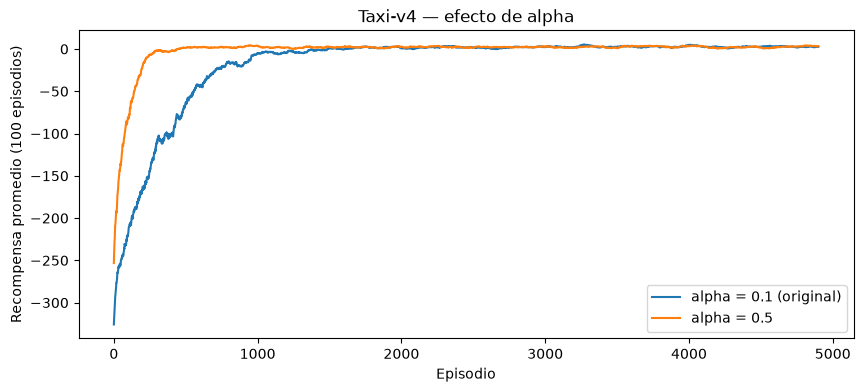

alpha=0.1: primer episodio con promedio móvil > 0: 1585 | promedio últimos 500 (con exploración): 2.77 | std últimos 500 episodios: 7.76
alpha=0.5: primer episodio con promedio móvil > 0: 546 | promedio últimos 500 (con exploración): 2.59 | std últimos 500 episodios: 7.17
alpha=0.1: greedy, 100 episodios -> recompensa media 7.63 ± 2.93, éxito 100%
alpha=0.5: greedy, 100 episodios -> recompensa media 7.59 ± 2.97, éxito 100%


In [18]:
def evaluate_greedy(env, Q, n_episodes=100, max_steps=200):
    totals, successes = [], 0
    for i in range(n_episodes):
        state, _ = env.reset(seed=1000 + i)
        total = 0
        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                successes += int(terminated)
                break
        totals.append(total)
    return np.mean(totals), np.std(totals), successes / n_episodes


random.seed(SEED); np.random.seed(SEED); env.reset(seed=SEED); env.action_space.seed(SEED)
Q_alpha05, rewards_alpha05 = train_q_learning(
    env,
    np.zeros((n_states, n_actions)),
    episodes=5000,
    alpha=0.5,
    gamma=0.95,
    epsilon=0.1
)

ma_base = np.convolve(rewards, np.ones(window) / window, mode="valid")
ma_a05 = np.convolve(rewards_alpha05, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(ma_base, label="alpha = 0.1 (original)")
plt.plot(ma_a05, label="alpha = 0.5")
plt.xlabel("Episodio")
plt.ylabel(f"Recompensa promedio ({window} episodios)")
plt.title("Taxi-v4 — efecto de alpha")
plt.legend()
plt.show()

for name, ma in [("alpha=0.1", ma_base), ("alpha=0.5", ma_a05)]:
    first = int(np.argmax(ma > 0)) + window if np.any(ma > 0) else None
    print(f"{name}: primer episodio con promedio móvil > 0: {first} | "
          f"promedio últimos 500 (con exploración): {np.mean(ma[-500:]):.2f} | "
          f"std últimos 500 episodios: {np.std((rewards if name=='alpha=0.1' else rewards_alpha05)[-500:]):.2f}")

for name, Qx in [("alpha=0.1", Q_trained), ("alpha=0.5", Q_alpha05)]:
    m, s, ok = evaluate_greedy(env, Qx)
    print(f"{name}: greedy, 100 episodios -> recompensa media {m:.2f} ± {s:.2f}, éxito {ok:.0%}")

**Respuesta:**

Se cambió **solo $\alpha$** de 0.1 a 0.5 (mismos $\gamma=0.95$, $\epsilon=0.1$, 5000 episodios, misma semilla).

- **Velocidad de aprendizaje:** con $\alpha=0.5$ el promedio móvil se vuelve positivo hacia el episodio ~546, frente a ~1585 con $\alpha=0.1$: aprende unas 3 veces más rápido, porque cada TD error corrige Q con un paso más grande.
- **Estabilidad:** en los últimos 500 episodios la desviación estándar de la recompensa es parecida (7.17 vs 7.76). Taxi es determinista, así que un $\alpha$ grande no genera inestabilidad visible; en un ambiente estocástico un $\alpha$ alto sí haría oscilar más los valores.
- **Recompensa final:** prácticamente igual. Con exploración, últimos 500 episodios: 2.59 vs 2.77. Política greedy en 100 episodios: $7.59 \pm 2.97$ vs $7.63 \pm 2.93$, ambos con 100 % de éxito.
- **Comportamiento observado:** ambos agentes resuelven el viaje correctamente; la diferencia está en cuántos episodios necesitan para llegar a una buena política, no en la política final.

## Entrega

El notebook debe contener:

1. implementación de `choose_action`;
2. implementación de `update_q`;
3. implementación de `train_q_learning`;
4. curva de aprendizaje;
5. visualización del agente antes y después del entrenamiento;
6. respuestas a las siete preguntas.

No es necesario modificar las funciones auxiliares de visualización.
